# attrib-EDITS · edits_l1 — the borrowed predictor

**Question (project #5):** what is the smallest *realistic* edit that flips a stability/fitness predictor — and does it match real ΔΔG?

This track **trains nothing**: the predictor is off-the-shelf. Here the miniature predictor is **ESM-2 used zero-shot** — one forward gives the log-probability of every residue at every position, so the model's fitness score for any sequence (and any single mutation) is a table lookup.

> ⚠️ **Read [`CLAUDE.md`](CLAUDE.md) first.** Because the predictor is borrowed, leakage lives between *its* training data and *our* eval set. The real ΔΔG validation (edits_l5) must run on a disjoint split.

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "edits"))   # for `import edits_common`
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
from edits_common import DEMO_SEQ, fitness, position_logp
print('WT (GB1 domain):', DEMO_SEQ)
print('len:', len(DEMO_SEQ), ' fitness(WT) =', round(fitness(DEMO_SEQ), 3))
lp = position_logp(DEMO_SEQ)
print('position_logp:', lp.shape, '(L x 20)')

WT (GB1 domain): MTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

len: 56  fitness(WT) = -14.559
position_logp: (56, 20) (L x 20)


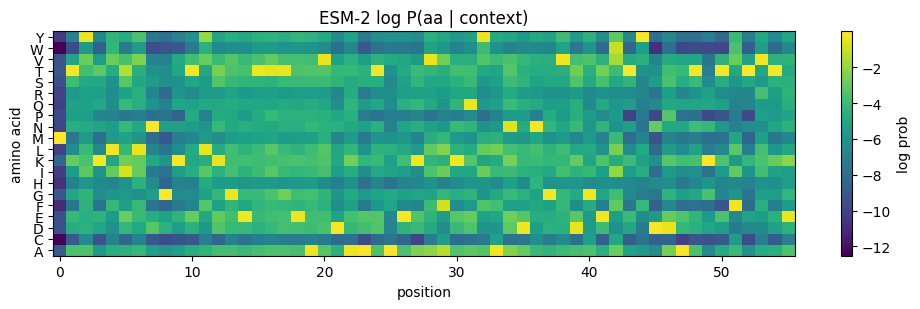

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3.2))
plt.imshow(lp.T, aspect='auto', cmap='viridis', origin='lower')
plt.yticks(range(20), list('ACDEFGHIKLMNPQRSTVWY'))
plt.xlabel('position'); plt.ylabel('amino acid'); plt.title('ESM-2 log P(aa | context)')
plt.colorbar(label='log prob'); plt.tight_layout(); plt.show()

### Things to experiment with
- Swap ESM-2 for **ESM-1v** (variant-effect specialist) — still sequence-only, mild leakage.
- The scale-up predictor is **ThermoMPNN** (Megascale-trained → severe leakage; see CLAUDE.md).